#1: Imports and Path Setup


In [1]:
import os
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Transformer_Mine

Mounted at /content/drive
/content/drive/MyDrive/Transformer_Mine


In [3]:
PROJECT_ROOT = '/content/drive/MyDrive/Transformer_Mine'
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'figures/attention')
WEIGHTS_PATH = os.path.join(
    PROJECT_ROOT, 'checkpoints/small_scale/weights_final.weights.h5'
)


In [4]:
os.makedirs(FIGURES_DIR, exist_ok=True)

from transformer_model import TiedTransformer
from tokenizer import BPETokenizer
from decoding import encode_source, decoder_mask_for, project_to_vocab

print("TensorFlow:", tf.__version__)
print("Project root:", PROJECT_ROOT)

TensorFlow: 2.20.0
Project root: /content/drive/MyDrive/Transformer_Mine


#2: Load Model

In [5]:
VOCAB_DIR_B = os.path.join(PROJECT_ROOT, 'vocab/stage_b')
tokenizer = BPETokenizer.load(VOCAB_DIR_B)
VOCAB_SIZE = tokenizer.vocab_size

In [6]:
MODEL_CONFIG = {
    'num_layers' : 3,
    'd_model' : 256,
    'num_heads' : 4,
    'd_ff' : 1024,
    'dropout' : 0.0,
    'max_len' : 100,
}

In [7]:
model = TiedTransformer(
    num_layers = MODEL_CONFIG['num_layers'],
    d_model = MODEL_CONFIG['d_model'],
    num_heads = MODEL_CONFIG['num_heads'],
    d_ff = MODEL_CONFIG['d_ff'],
    src_vocab = VOCAB_SIZE,
    tgt_vocab = VOCAB_SIZE,
    max_len = MODEL_CONFIG['max_len'],
    dropout = MODEL_CONFIG['dropout'],
)

In [8]:
safe_id = min(100, VOCAB_SIZE - 1)
build_src = tf.constant([[safe_id] * 10], dtype=tf.int32)
build_tgt = tf.constant([[tokenizer.bos_id] + [safe_id] * 9], dtype=tf.int32)
_ = model(build_src, build_tgt, training=False)

model.load_weights(WEIGHTS_PATH)
print(f"Model loaded from: {WEIGHTS_PATH}")
print(f"  Vocab size : {VOCAB_SIZE}")
print(f"  Parameters : "
      f"{sum(tf.size(w).numpy() for w in model.trainable_variables):,}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_self_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_self_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_cross_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will no

Model loaded from: /content/drive/MyDrive/Transformer_Mine/checkpoints/small_scale/weights_final.weights.h5
  Vocab size : 8000
  Parameters : 9,616,384


# 3: Attention Extraction

Runs a full forward pass and collects all attention weights.

Returns weights for:

* All encoder self-attention layers
* All decoder self-attention layers
* All decoder cross-attention layers

**Attention weight shape per layer:**

```text
encoder self   : (1, num_heads, src_len, src_len)
decoder self   : (1, num_heads, tgt_len, tgt_len)
decoder cross  : (1, num_heads, tgt_len, src_len)
```


In [9]:
def get_attention_weights(model, src_text, tgt_text, tokenizer, max_len=50):
    """
    Run a full forward pass and extract all attention weights.

    Args:
        model : trained TiedTransformer
        src_text : raw source string
        tgt_text : raw target string (used as decoder input)
        tokenizer : BPETokenizer
        max_len : max sequence length

    Returns:
        src_tokens : list of source token strings
        tgt_tokens : list of target token strings
        enc_weights : dict layer_name -> (num_heads, src_len, src_len)
        dec_self_w : dict layer_name -> (num_heads, tgt_len, tgt_len)
        dec_cross_w : dict layer_name -> (num_heads, tgt_len, src_len)
    """

    # Tokenise source
    src_ids = tokenizer.encode_with_special(src_text)[:max_len]
    src_ids_pad = src_ids + [tokenizer.pad_id] * (max_len - len(src_ids))
    src_tensor = tf.constant([src_ids_pad], dtype=tf.int32)

    # Tokenise target (decoder input: BOS + tokens, no EOS)
    tgt_ids = [tokenizer.bos_id] + tokenizer.encode(tgt_text)
    tgt_ids = tgt_ids[:max_len]
    tgt_ids_pad = tgt_ids + [tokenizer.pad_id] * (max_len - len(tgt_ids))
    tgt_tensor = tf.constant([tgt_ids_pad], dtype=tf.int32)

    # Masks
    enc_mask = tf.cast(
        tf.equal(src_tensor, tokenizer.pad_id), tf.float32
    )[:, tf.newaxis, tf.newaxis, :]
    dec_mask = tf.maximum(
        1.0 - tf.linalg.band_part(
            tf.ones((1, 1, len(tgt_ids), len(tgt_ids))), -1, 0
        ),
        tf.cast(
            tf.equal(tgt_tensor[:, :len(tgt_ids)], tokenizer.pad_id),
            tf.float32
        )[:, tf.newaxis, tf.newaxis, :],
    )

    # Forward pass — collect attention weights
    _, all_attn = model(
        src_tensor,
        tgt_tensor,
        training=False,
    )

    # Decode tokens for axis labels (strip PAD and special tokens)
    def ids_to_tokens(ids):
        tokens = []
        for i in ids:
            if i in (tokenizer.pad_id,):
                break
            tokens.append(tokenizer.id2token.get(int(i), '?'))
        return tokens

    src_tokens = ids_to_tokens(src_ids)
    tgt_tokens = ids_to_tokens(tgt_ids[1:])  # skip BOS for display

    # Separate encoder and decoder weights
    enc_weights = {}
    dec_self_w = {}
    dec_cross_w = {}

    for key, weights in all_attn.items():
        # weights shape: (1, num_heads, seq_q, seq_k)
        w = weights[0].numpy()  # remove batch dim → (heads, q, k)

        if 'encoder' in key:
            # Trim to actual src_len
            w = w[:, :len(src_tokens), :len(src_tokens)]
            enc_weights[key] = w
        elif 'self' in key:
            w = w[:, :len(tgt_tokens), :len(tgt_tokens)]
            dec_self_w[key] = w
        elif 'cross' in key:
            w = w[:, :len(tgt_tokens), :len(src_tokens)]
            dec_cross_w[key] = w

    return src_tokens, tgt_tokens, enc_weights, dec_self_w, dec_cross_w


#4: Plot Single Attention Head

In [10]:
def plot_attention_head(
    weights,
    row_labels,
    col_labels,
    title='',
    ax=None,
    figsize=(7, 5),
):
    """
    Plot a single attention weight matrix as a heatmap.

    Args:
        weights : (seq_q, seq_k) numpy array
        row_labels : list of query token strings
        col_labels : list of key token strings
        title : plot title
        ax : existing matplotlib axis (optional)
        figsize : figure size if creating new figure

    Returns:
        fig, ax
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    im = ax.imshow(weights, cmap='Blues', aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(range(len(col_labels)))
    ax.set_yticks(range(len(row_labels)))
    ax.set_xticklabels(
        [t.replace('</w>', '') for t in col_labels],
        rotation=45, ha='right', fontsize=9,
    )
    ax.set_yticklabels(
        [t.replace('</w>', '') for t in row_labels],
        fontsize=9,
    )

    ax.set_xlabel('Keys (source)', fontsize=10)
    ax.set_ylabel('Queries (target)', fontsize=10)
    ax.set_title(title, fontsize=10)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    return fig, ax



# 5: Encoder Self-Attention

Shows how each source token attends to other source tokens.

Good encoder self-attention captures:

* Subject-verb relationships
* Adjective-noun relationships
* Coreference links


Source tokens : ['<bos>', 'I</w>', 'am</w>', 'a</w>', 'student</w>', '.</w>', '<eos>']
Target tokens : ['Ich</w>', 'bin</w>', 'ein</w>', 'Student</w>', '.</w>']



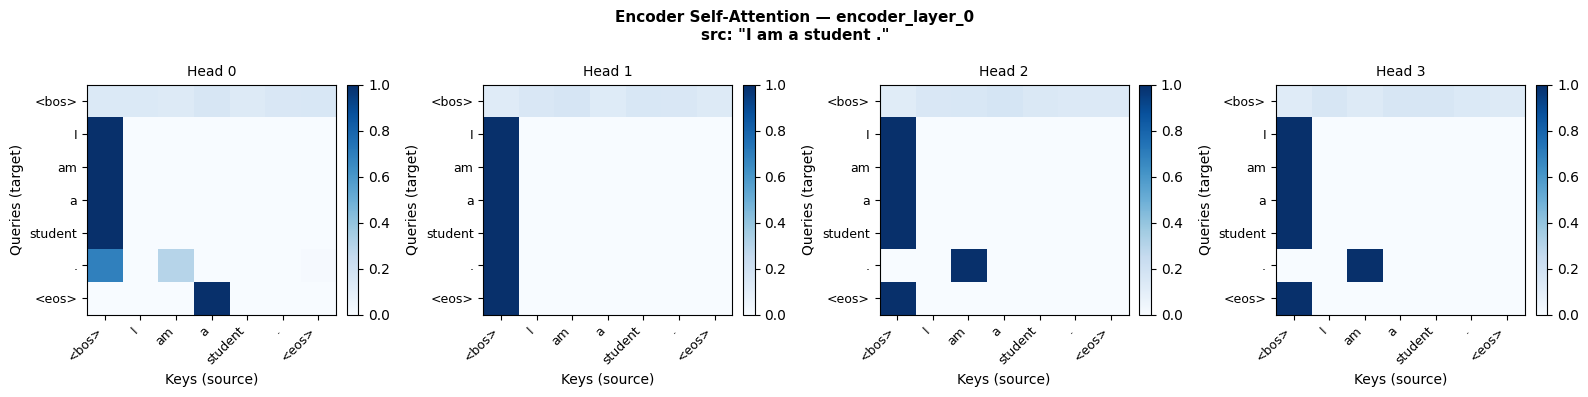

Saved: /content/drive/MyDrive/Transformer_Mine/figures/attention/enc_self_encoder_layer_0.png


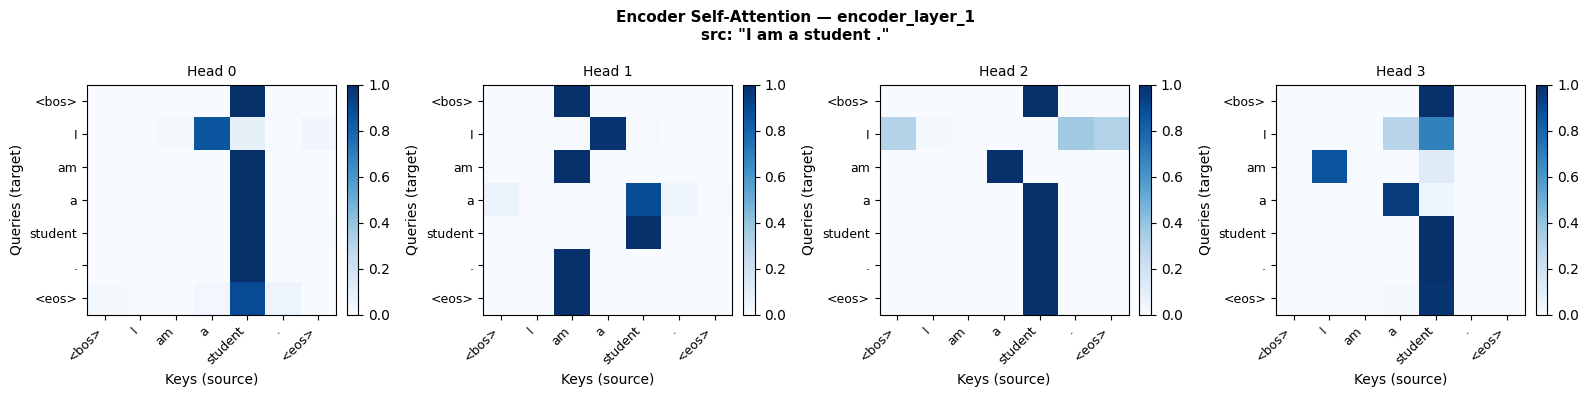

Saved: /content/drive/MyDrive/Transformer_Mine/figures/attention/enc_self_encoder_layer_1.png


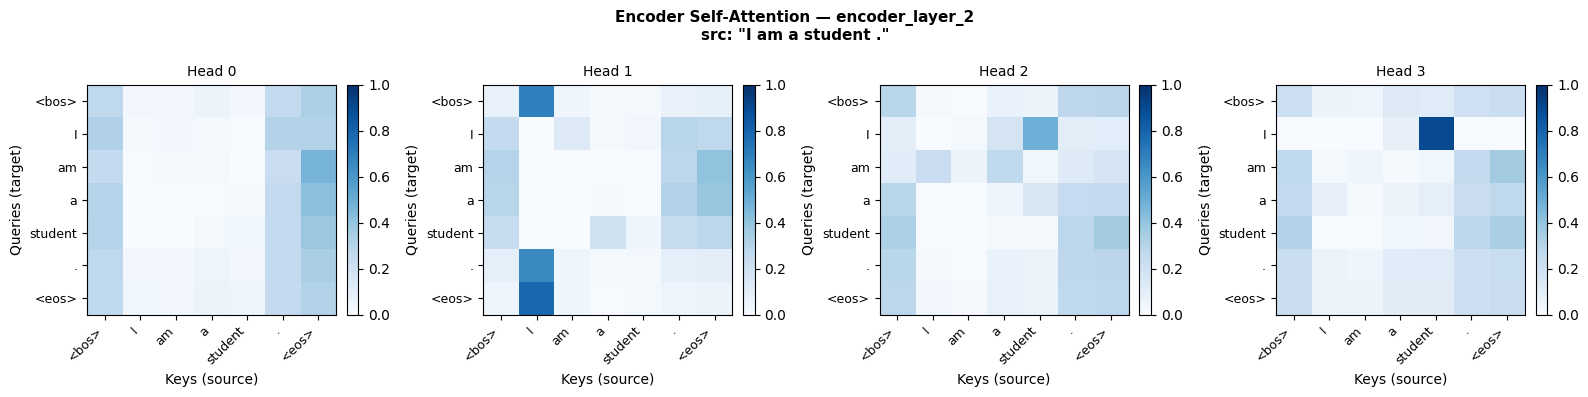

Saved: /content/drive/MyDrive/Transformer_Mine/figures/attention/enc_self_encoder_layer_2.png


In [11]:
src_text = "I am a student ."
tgt_text = "Ich bin ein Student ."

src_tokens, tgt_tokens, enc_weights, dec_self_w, dec_cross_w = \
    get_attention_weights(model, src_text, tgt_text, tokenizer)

print(f"Source tokens : {src_tokens}")
print(f"Target tokens : {tgt_tokens}")
print()

# Plot all heads for each encoder layer
for layer_name, weights in enc_weights.items():
    # weights shape: (num_heads, src_len, src_len)
    num_heads = weights.shape[0]

    fig, axes = plt.subplots(
        1, num_heads,
        figsize=(4 * num_heads, 4),
    )
    if num_heads == 1:
        axes = [axes]

    for h, ax in enumerate(axes):
        plot_attention_head(
            weights[h],
            row_labels = src_tokens,
            col_labels = src_tokens,
            title      = f'Head {h}',
            ax         = ax,
        )

    fig.suptitle(
        f'Encoder Self-Attention — {layer_name}\n'
        f'src: "{src_text}"',
        fontsize=11, fontweight='bold',
    )
    plt.tight_layout()

    fig_path = os.path.join(
        FIGURES_DIR, f'enc_self_{layer_name}.png'
    )
    plt.savefig(fig_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fig_path}")

# 6: Decoder Cross-Attention

Cross-attention shows which source tokens each target token attends to. This is the most linguistically interpretable attention type — it reveals alignment between source and target.

For a well-trained model:

* `"Student"` → attends strongly to `"student"`
* `"Ich"` → attends to `"I"`
* `"bin"` → attends to `"am"`

At this scale (10k steps, 80k pairs) alignment may be noisy but should show some structure.


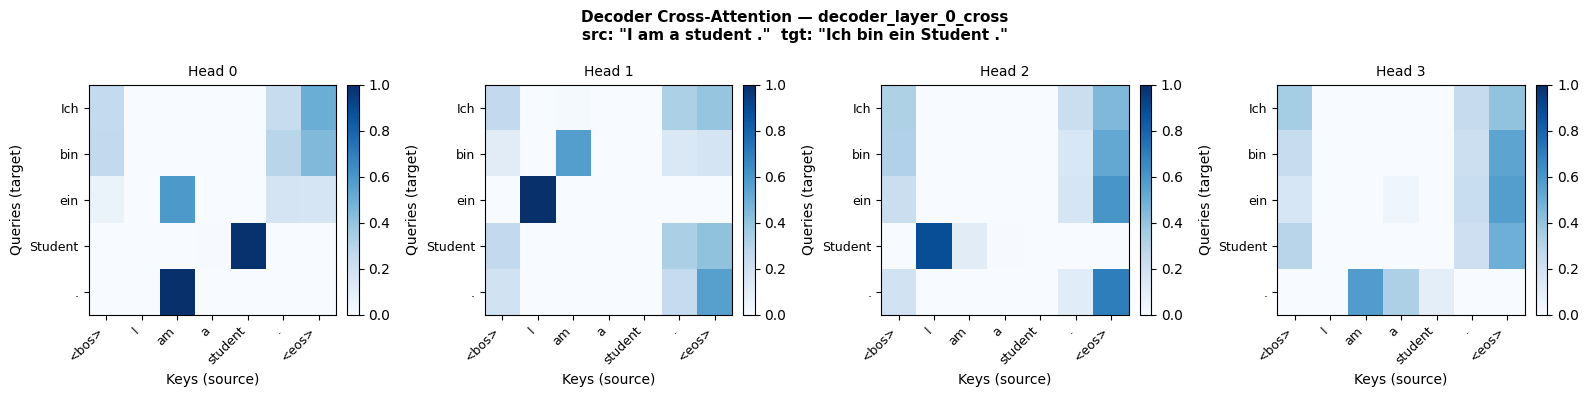

Saved: /content/drive/MyDrive/Transformer_Mine/figures/attention/dec_cross_decoder_layer_0_cross.png


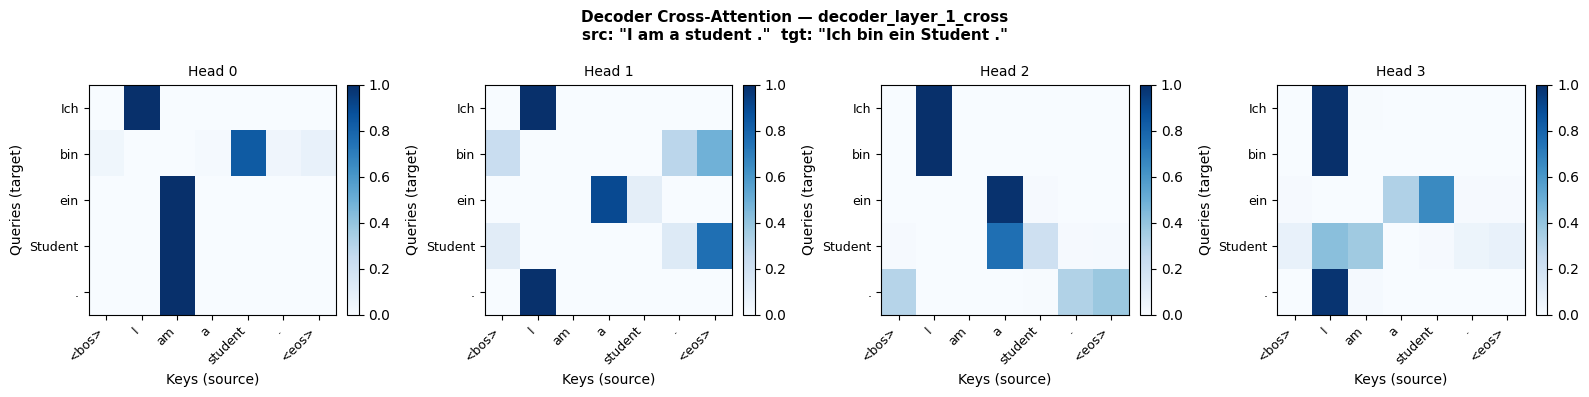

Saved: /content/drive/MyDrive/Transformer_Mine/figures/attention/dec_cross_decoder_layer_1_cross.png


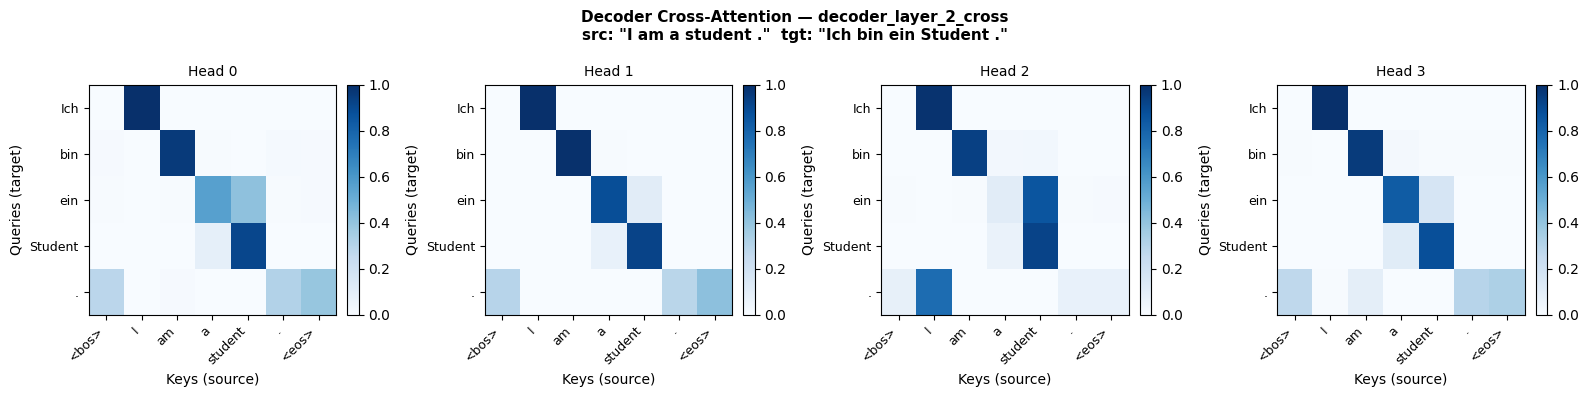

Saved: /content/drive/MyDrive/Transformer_Mine/figures/attention/dec_cross_decoder_layer_2_cross.png


In [12]:
for layer_name, weights in dec_cross_w.items():
    # weights shape: (num_heads, tgt_len, src_len)
    num_heads = weights.shape[0]

    fig, axes = plt.subplots(
        1, num_heads,
        figsize=(4 * num_heads, max(4, len(tgt_tokens) * 0.6)),
    )
    if num_heads == 1:
        axes = [axes]

    for h, ax in enumerate(axes):
        plot_attention_head(
            weights[h],
            row_labels = tgt_tokens,
            col_labels = src_tokens,
            title      = f'Head {h}',
            ax         = ax,
        )

    fig.suptitle(
        f'Decoder Cross-Attention — {layer_name}\n'
        f'src: "{src_text}"  tgt: "{tgt_text}"',
        fontsize=11, fontweight='bold',
    )
    plt.tight_layout()

    fig_path = os.path.join(
        FIGURES_DIR, f'dec_cross_{layer_name}.png'
    )
    plt.savefig(fig_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fig_path}")

# 7: Decoder Self-Attention

Decoder self-attention is causal — each target token can only attend to itself and previous target tokens.

The lower-triangular pattern should be clearly visible.


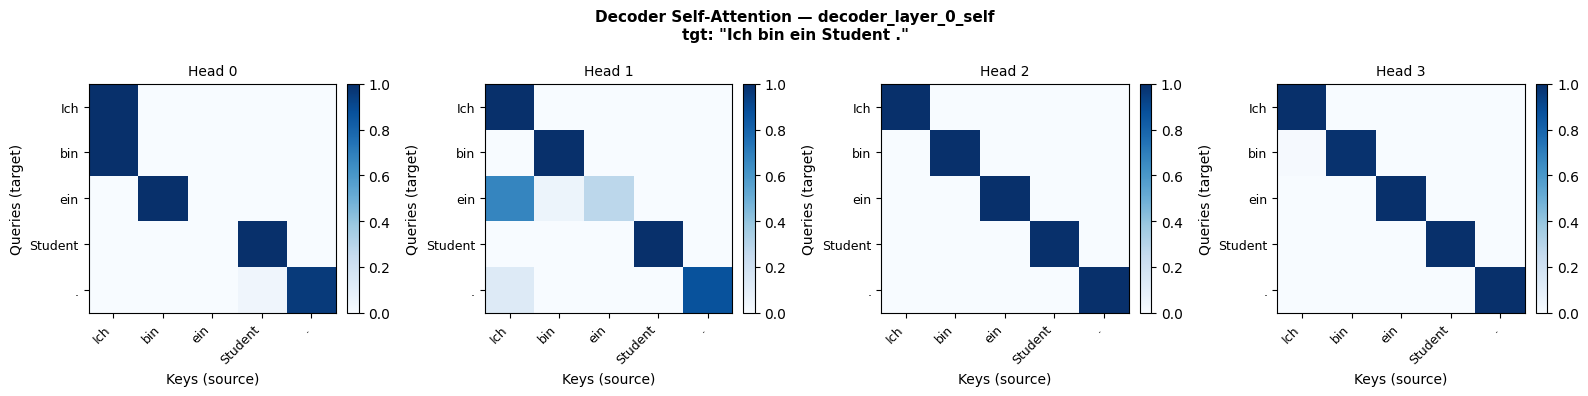

Saved: /content/drive/MyDrive/Transformer_Mine/figures/attention/dec_self_decoder_layer_0_self.png


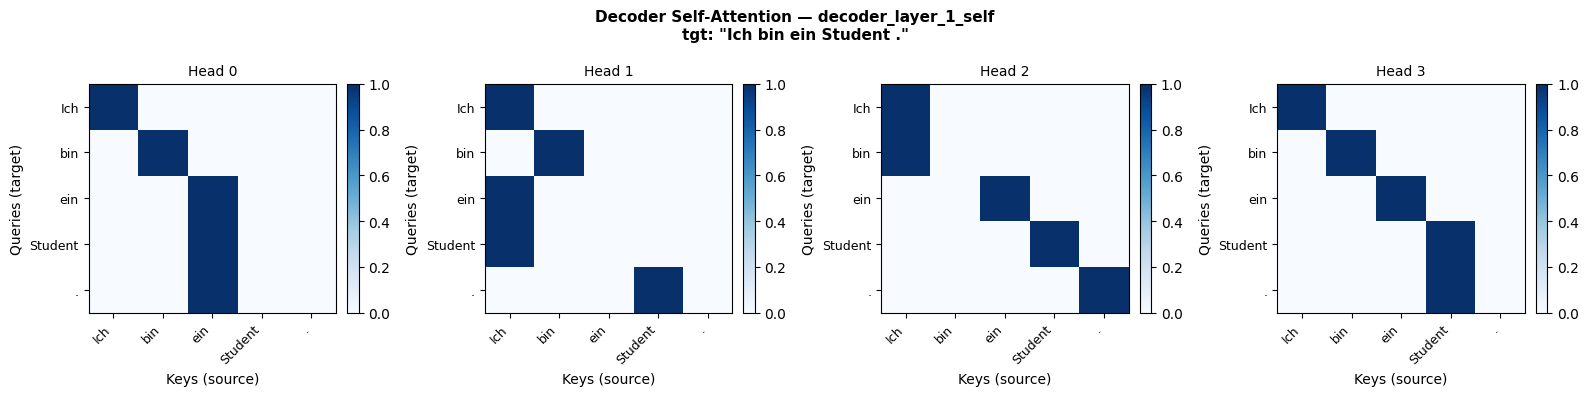

Saved: /content/drive/MyDrive/Transformer_Mine/figures/attention/dec_self_decoder_layer_1_self.png


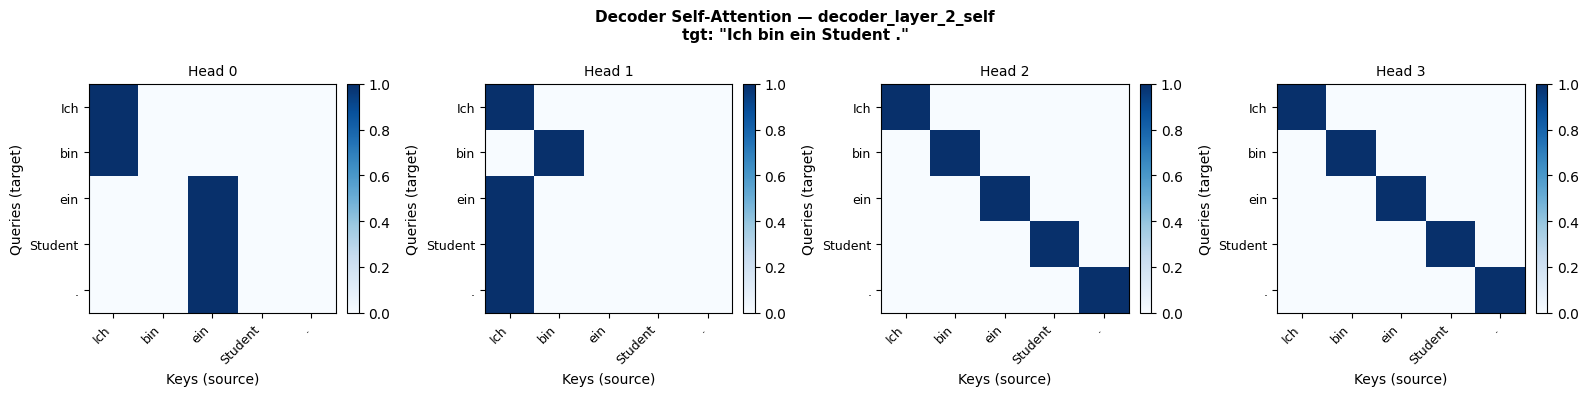

Saved: /content/drive/MyDrive/Transformer_Mine/figures/attention/dec_self_decoder_layer_2_self.png

Causal mask verification in decoder self-attention:
  decoder_layer_0_self: 0 causal violations
  decoder_layer_1_self: 0 causal violations
  decoder_layer_2_self: 0 causal violations


In [13]:
for layer_name, weights in dec_self_w.items():
    num_heads = weights.shape[0]

    fig, axes = plt.subplots(
        1, num_heads,
        figsize=(4 * num_heads, max(4, len(tgt_tokens) * 0.6)),
    )
    if num_heads == 1:
        axes = [axes]

    for h, ax in enumerate(axes):
        plot_attention_head(
            weights[h],
            row_labels = tgt_tokens,
            col_labels = tgt_tokens,
            title      = f'Head {h}',
            ax         = ax,
        )

    fig.suptitle(
        f'Decoder Self-Attention — {layer_name}\n'
        f'tgt: "{tgt_text}"',
        fontsize=11, fontweight='bold',
    )
    plt.tight_layout()

    fig_path = os.path.join(
        FIGURES_DIR, f'dec_self_{layer_name}.png'
    )
    plt.savefig(fig_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fig_path}")

# Verify causal property from the plots
print()
print("Causal mask verification in decoder self-attention:")
for layer_name, weights in dec_self_w.items():
    violations = 0
    for h in range(weights.shape[0]):
        for i in range(weights.shape[1]):
            for j in range(i + 1, weights.shape[2]):
                if weights[h, i, j] > 1e-6:
                    violations += 1
    print(f"  {layer_name}: {violations} causal violations")

# 8: Multi-Sentence Cross-Attention

Visualises cross-attention for several sentence pairs to check whether alignment patterns are consistent or noisy.

Uses only the last decoder layer's averaged attention (mean across heads) for a cleaner view.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_self_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_self_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_cross_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will no

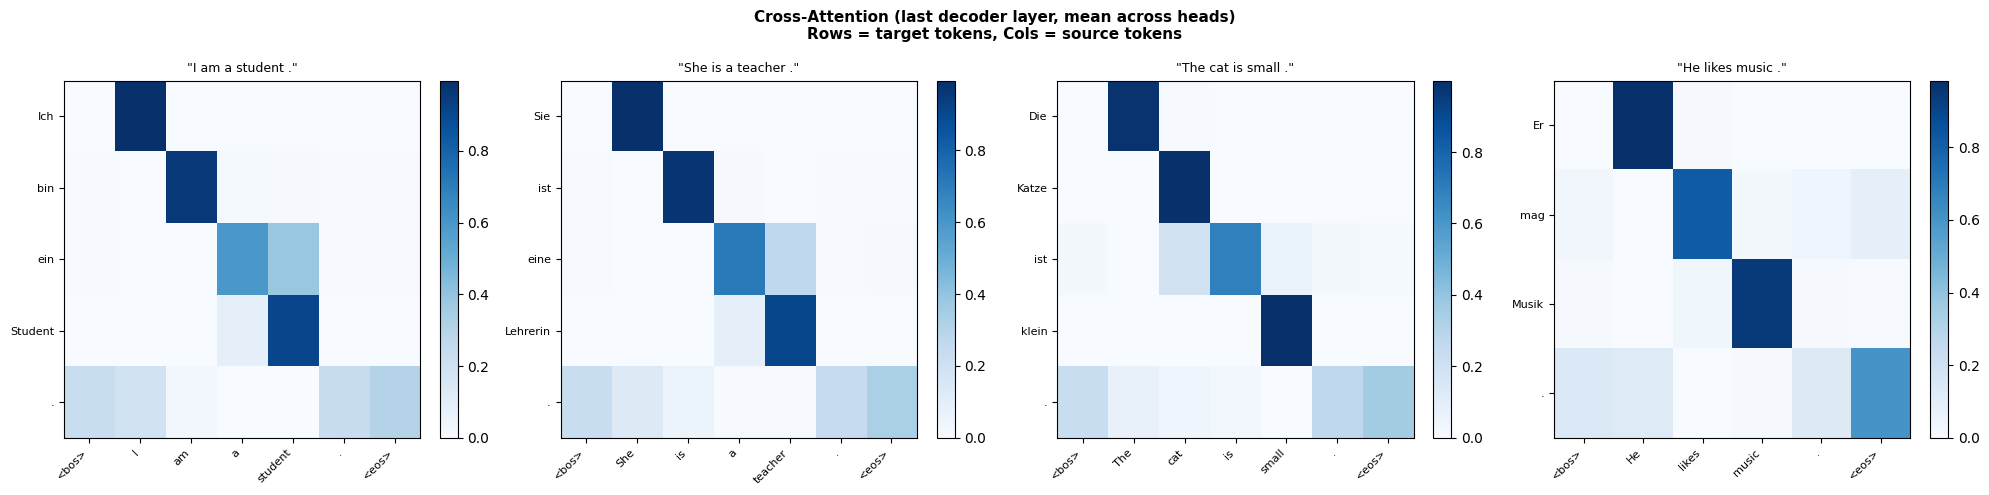

Multi-sentence cross-attention saved: /content/drive/MyDrive/Transformer_Mine/figures/attention/cross_attention_multi_sentence.png


In [14]:
import re

def normalise_token(t):
    """Strip </w> and clean for display."""
    return t.replace('</w>', '')

test_pairs = [
    ("I am a student .", "Ich bin ein Student ."),
    ("She is a teacher .", "Sie ist eine Lehrerin ."),
    ("The cat is small .", "Die Katze ist klein ."),
    ("He likes music .", "Er mag Musik ."),
]

fig, axes = plt.subplots(
    1, len(test_pairs),
    figsize=(5 * len(test_pairs), 5),
)

for ax, (src_t, tgt_t) in zip(axes, test_pairs):
    src_tok, tgt_tok, _, _, cross_w = \
        get_attention_weights(model, src_t, tgt_t, tokenizer)

    # Use last decoder cross-attention layer, average across heads
    last_key    = sorted(cross_w.keys())[-1]
    avg_weights = cross_w[last_key].mean(axis=0)
    # avg_weights shape: (tgt_len, src_len)

    im = ax.imshow(avg_weights, cmap='Blues', aspect='auto', vmin=0)
    ax.set_xticks(range(len(src_tok)))
    ax.set_yticks(range(len(tgt_tok)))
    ax.set_xticklabels(
        [normalise_token(t) for t in src_tok],
        rotation=45, ha='right', fontsize=8,
    )
    ax.set_yticklabels(
        [normalise_token(t) for t in tgt_tok],
        fontsize=8,
    )
    ax.set_title(f'"{src_t[:20]}"', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(
    'Cross-Attention (last decoder layer, mean across heads)\n'
    'Rows = target tokens, Cols = source tokens',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, 'cross_attention_multi_sentence.png')
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()

print(f"Multi-sentence cross-attention saved: {fig_path}")

# 9: Attention Head Specialisation

Checks whether different attention heads learn different patterns.

Computes pairwise similarity between heads in the last decoder cross-attention layer.

* Low similarity = heads are specialised.
* High similarity = heads are redundant.


In [15]:
src_text = "I am a student ."
tgt_text = "Ich bin ein Student ."

src_tok, tgt_tok, _, _, cross_w = \
    get_attention_weights(model, src_text, tgt_text, tokenizer)

last_key = sorted(cross_w.keys())[-1]
weights  = cross_w[last_key]
# weights shape: (num_heads, tgt_len, src_len)

num_heads = weights.shape[0]

print(f"Head specialisation analysis — {last_key}")
print(f"  Num heads : {num_heads}")
print()

# Pairwise cosine similarity between head attention patterns
flat = weights.reshape(num_heads, -1)
norms = np.linalg.norm(flat, axis=1, keepdims=True)
flat_norm = flat / (norms + 1e-8)
sim_matrix = flat_norm @ flat_norm.T

print("Pairwise cosine similarity between heads:")
print(f"  {'':>6}", end='')
for h in range(num_heads):
    print(f"  head{h}", end='')
print()
for i in range(num_heads):
    print(f"  head{i}", end='')
    for j in range(num_heads):
        print(f"  {sim_matrix[i,j]:.3f}", end='')
    print()

mean_off_diag = (sim_matrix.sum() - np.trace(sim_matrix)) / \
                (num_heads * (num_heads - 1))
print(f"\nMean off-diagonal similarity : {mean_off_diag:.4f}")
print(f"  < 0.5 : heads are reasonably specialised")
print(f"  > 0.9 : heads are nearly redundant")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_self_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_self_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_cross_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will no

Head specialisation analysis — decoder_layer_2_cross
  Num heads : 4

Pairwise cosine similarity between heads:
          head0  head1  head2  head3
  head0  1.000  0.975  0.846  0.980
  head1  0.975  1.000  0.756  0.997
  head2  0.846  0.756  1.000  0.776
  head3  0.980  0.997  0.776  1.000

Mean off-diagonal similarity : 0.8883
  < 0.5 : heads are reasonably specialised
  > 0.9 : heads are nearly redundant


#10: Save Summary Figure

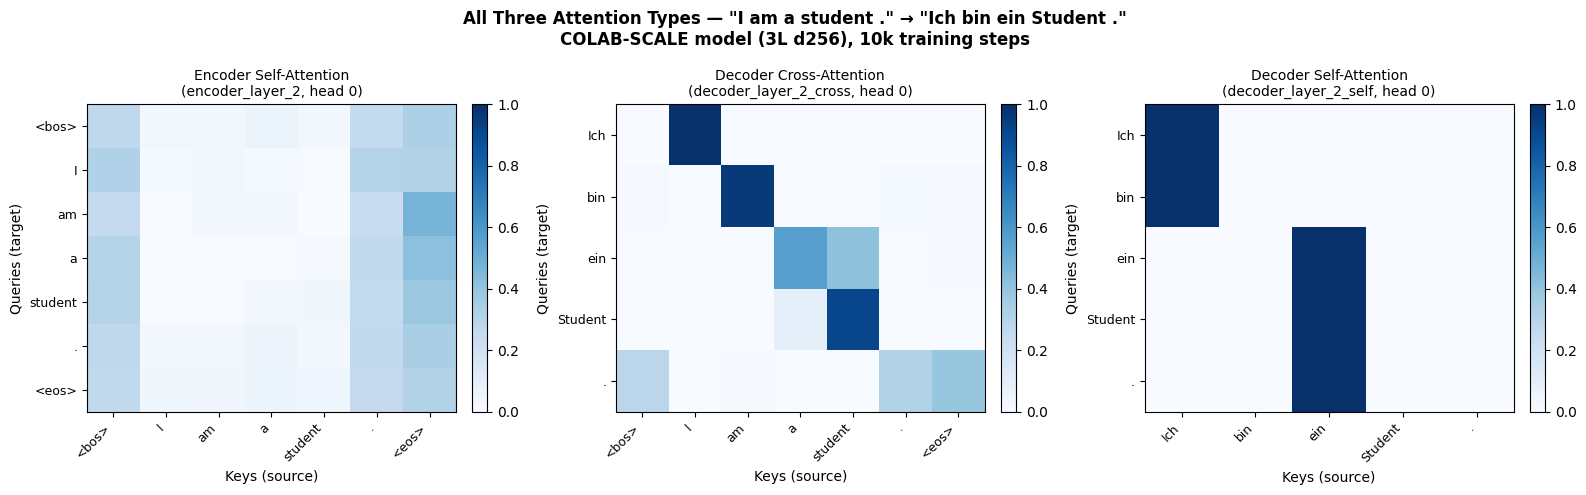

Summary figure saved: /content/drive/MyDrive/Transformer_Mine/figures/attention/attention_summary.png

What to look for in the plots:
  Encoder self-attn  : structure in how source tokens relate
  Decoder cross-attn : rough alignment between src and tgt tokens
  Decoder self-attn  : lower-triangular causal pattern

What NOT to over-interpret:
  Attention is not the same as explanation or importance.
  A token attending strongly to another does not mean
  that relationship is causally responsible for the output.
  Treat these as exploratory visualisations, not ground truth.



In [16]:
src_text = "I am a student ."
tgt_text = "Ich bin ein Student ."

src_tok, tgt_tok, enc_w, dec_self, dec_cross = \
    get_attention_weights(model, src_text, tgt_text, tokenizer)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Encoder self-attention (last layer, head 0)
enc_last  = sorted(enc_w.keys())[-1]
plot_attention_head(
    enc_w[enc_last][0],
    row_labels = src_tok,
    col_labels = src_tok,
    title      = f'Encoder Self-Attention\n({enc_last}, head 0)',
    ax         = axes[0],
)

# Panel 2: Decoder cross-attention (last layer, head 0)
cross_last = sorted(dec_cross.keys())[-1]
plot_attention_head(
    dec_cross[cross_last][0],
    row_labels = tgt_tok,
    col_labels = src_tok,
    title      = f'Decoder Cross-Attention\n({cross_last}, head 0)',
    ax         = axes[1],
)

# Panel 3: Decoder self-attention (last layer, head 0)
self_last = sorted(dec_self.keys())[-1]
plot_attention_head(
    dec_self[self_last][0],
    row_labels = tgt_tok,
    col_labels = tgt_tok,
    title      = f'Decoder Self-Attention\n({self_last}, head 0)',
    ax         = axes[2],
)

fig.suptitle(
    f'All Three Attention Types — "{src_text}" → "{tgt_text}"\n'
    f'COLAB-SCALE model (3L d256), 10k training steps',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()

summary_path = os.path.join(FIGURES_DIR, 'attention_summary.png')
plt.savefig(summary_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Summary figure saved: {summary_path}")
print()
print("What to look for in the plots:")
print("  Encoder self-attn  : structure in how source tokens relate")
print("  Decoder cross-attn : rough alignment between src and tgt tokens")
print("  Decoder self-attn  : lower-triangular causal pattern")
print()
print("What NOT to over-interpret:")
print("  Attention is not the same as explanation or importance.")
print("  A token attending strongly to another does not mean")
print("  that relationship is causally responsible for the output.")
print("  Treat these as exploratory visualisations, not ground truth.")
print()